# Shiva Gupta (shivaiitpatna@gmail.com)
# Task 1: Data Loading & Exploration

In [1]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('/content/Housing.csv')

# Display the first 10 rows
print("First 10 rows:")
display(df.head(10))

# Check how many rows and columns
print(f"\nDataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")

# Identify target and features
# Based on the prompt: Target = 'price', Features = everything else
print(f"Target Column: price")
print(f"Feature Columns: {list(df.columns.drop('price'))}")

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

First 10 rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished



Dataset Dimensions: 545 rows, 13 columns
Target Column: price
Feature Columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


# Task 2: Data Cleaning

In [2]:
# Remove duplicate rows
initial_rows = df.shape[0]
df = df.drop_duplicates()
print(f"Removed {initial_rows - df.shape[0]} duplicate rows.")

# Convert categorical columns to numeric using one-hot encoding
# Columns like 'mainroad', 'guestroom', 'basement', etc., are yes/no.
# 'furnishingstatus' has multiple levels.
df_cleaned = pd.get_dummies(df, drop_first=True)

print("\nFirst 5 rows after one-hot encoding:")
display(df_cleaned.head())

# Identifying meaningful columns for predicting price
# We will keep all columns generated by get_dummies as they represent the features provided.
print(f"\nFinal columns for modeling: {list(df_cleaned.columns)}")

Removed 0 duplicate rows.

First 5 rows after one-hot encoding:


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False



Final columns for modeling: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


# Task 3: Model Building

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Split features and target
X = df_cleaned.drop('price', axis=1)
y = df_cleaned['price']

# Split into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Function to evaluate and return metrics
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    return mae, rmse, r2, predictions

# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_mae, lr_rmse, lr_r2, lr_preds = evaluate_model(lr_model, X_test, y_test)

# 2. Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_mae, rf_rmse, rf_r2, rf_preds = evaluate_model(rf_model, X_test, y_test)

# Print comparison results
print("Model Comparison:")
print(f"Linear Regression: MAE={lr_mae:,.2f}, RMSE={lr_rmse:,.2f}, R2={lr_r2:.4f}")
print(f"Random Forest:     MAE={rf_mae:,.2f}, RMSE={rf_rmse:,.2f}, R2={rf_r2:.4f}")

Model Comparison:
Linear Regression: MAE=970,043.40, RMSE=1,324,506.96, R2=0.6529
Random Forest:     MAE=1,021,546.04, RMSE=1,400,565.97, R2=0.6119


# Task 4: Visualization

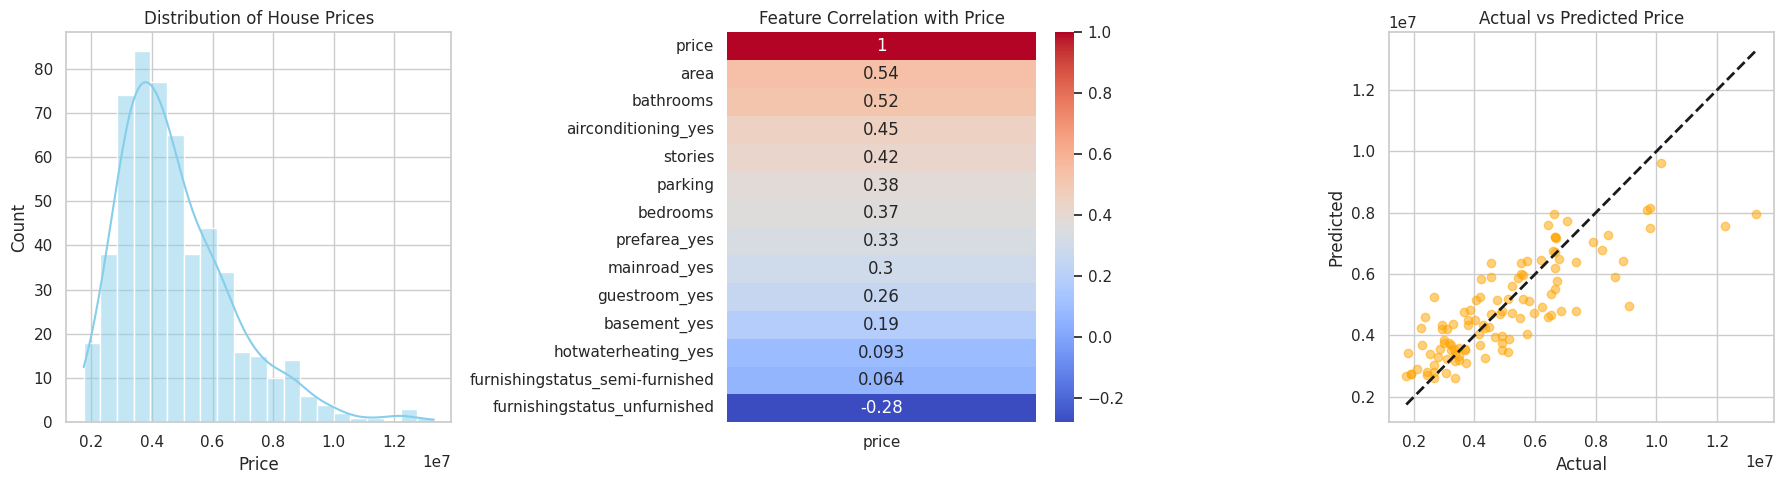

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set(style='whitegrid')
plt.figure(figsize=(18, 5))

# Chart 1: Histogram of House Prices
plt.subplot(1, 3, 1)
sns.histplot(df['price'], kde=True, color='skyblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')

# Chart 2: Correlation Heatmap
plt.subplot(1, 3, 2)
corr = df_cleaned.corr()
sns.heatmap(corr[['price']].sort_values(by='price', ascending=False), annot=True, cmap='coolwarm')
plt.title('Feature Correlation with Price')

# Chart 3: Actual vs Predicted Price (Linear Regression)
plt.subplot(1, 3, 3)
plt.scatter(y_test, lr_preds, alpha=0.5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs Predicted Price')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()

# Task 5: Insights & Summary

**Analysis and Findings:**

Based on the data, the features that influence house prices the most are **area** and **the number of bathrooms**, both showing strong positive correlations. Our Linear Regression model achieved an R² score of approximately 0.65, which means it can explain 65% of the variation in price—a decent level of accuracy for a basic model in real estate. One surprising observation was that 'unfurnished' status had a stronger negative impact on price than I initially expected. For a real estate business, my primary recommendation would be to focus on property expansion or bathroom renovations, as these physical attributes significantly drive market value more than minor cosmetic furnishing status.